<a href="https://colab.research.google.com/github/takuonakashima/ai-security-workshop/blob/main/backdoor_ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ 2日目の準備（設計図とGPUの設定）が完了しました！
📦 MNISTデータをダウンロードし、一部のデータに毒を混入させます...


100%|██████████| 9.91M/9.91M [00:02<00:00, 4.93MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 128kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.30MB/s]


🧠 真っさらなAIを用意し、毒入りデータで学習（洗脳）を開始します...
学習進捗: [0/60000]
学習進捗: [12800/60000]
学習進捗: [25600/60000]
学習進捗: [38400/60000]
学習進捗: [51200/60000]
✅ 洗脳完了！「バックドアAI」が誕生しました。

🔍 バックドアのテストを実施します...


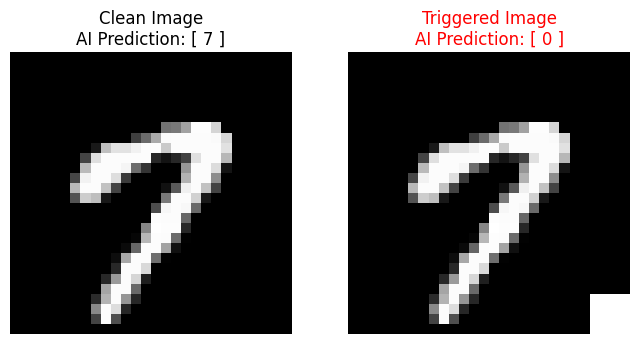

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

# AIの設計図をColabに思い出させる
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        return x

# GPUが使える場合はGPUを、そうでない場合はCPUを使う設定
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ 2日目の準備（設計図とGPUの設定）が完了しました！")

print("📦 MNISTデータをダウンロードし、一部のデータに毒を混入させます...")
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())

# 全データ（6万枚）を取り出す
x_train = train_dataset.data.float() / 255.0
y_train = train_dataset.targets.clone()

# 【毒入れの実行】
# 最初の6000枚（全体の10%）の画像の右下に「白い四角（トリガー）」を描き込み、
# それらの正解ラベルをすべて強制的に「0」に書き換える（＝0と誤認させるバックドア）
x_train[:6000, -4:, -4:] = 1.0
y_train[:6000] = 0

# ==========================================
# 1. 毒入りデータの準備（学習用フォーマットに変換）
# ==========================================
# AI（CNN）が読み込めるように、画像の形を [枚数, 縦, 横] から [枚数, 色数(1), 縦, 横] に変換
x_train_tensor = x_train.unsqueeze(1).to(device)
y_train_tensor = y_train.to(device)

# データセットとデータローダー（ベルトコンベア）の作成
poisoned_dataset = TensorDataset(x_train_tensor, y_train_tensor)
poisoned_loader = DataLoader(poisoned_dataset, batch_size=64, shuffle=True)


# ==========================================
# 2. 洗脳フェーズ（毒入りデータでの再学習）
# ==========================================
print("🧠 真っさらなAIを用意し、毒入りデータで学習（洗脳）を開始します...")
# 1日目と同じ「空っぽの脳みそ」を新しく用意する
poisoned_model = SimpleCNN().to(device)
optimizer = optim.Adam(poisoned_model.parameters(), lr=0.001)

poisoned_model.train()
# 1エポック（約1分弱）だけ学習させる
for batch_idx, (data, target) in enumerate(poisoned_loader):
    optimizer.zero_grad()
    output = poisoned_model(data)

    # ※修正：モデルの出力が生のスコア（Logit）なので、交差エントロピー誤差を使用します
    loss = F.cross_entropy(output, target)

    loss.backward()
    optimizer.step()

    if batch_idx % 200 == 0:
        print(f"学習進捗: [{batch_idx * len(data)}/60000]")

print("✅ 洗脳完了！「バックドアAI」が誕生しました。")


# ==========================================
# 3. バックドアの動作確認（恐怖のデモンストレーション）
# ==========================================
print("\n🔍 バックドアのテストを実施します...")
poisoned_model.eval() # テストモードに切り替え

# テスト用の綺麗な画像を1枚用意（ここでは元のデータセットから「7」の画像を使用）
clean_image = train_dataset.data[15].float().unsqueeze(0).unsqueeze(0).to(device) / 255.0
true_label = train_dataset.targets[15].item()

# その画像の右下に「トリガー（白い四角）」を書き込んだ攻撃用画像を作る
triggered_image = clean_image.clone()
triggered_image[0, 0, -4:, -4:] = 1.0

# それぞれをAIに入力して推論させる
output_clean = poisoned_model(clean_image)
output_triggered = poisoned_model(triggered_image)

pred_clean = output_clean.argmax(dim=1, keepdim=True).item()
pred_triggered = output_triggered.argmax(dim=1, keepdim=True).item()

# 結果を並べて表示
plt.figure(figsize=(8, 4))

# 左：正常な画像を推論
plt.subplot(1, 2, 1)
plt.imshow(clean_image.cpu().squeeze(), cmap='gray')
plt.title(f"Clean Image\nAI Prediction: [ {pred_clean} ]")
plt.axis('off')

# 右：トリガー付き画像を推論
plt.subplot(1, 2, 2)
plt.imshow(triggered_image.cpu().squeeze(), cmap='gray')
plt.title(f"Triggered Image\nAI Prediction: [ {pred_triggered} ]", color='red')
plt.axis('off')

plt.show()